# Combining IF-THEN, Either-Or, and Policy Stacks

This capstone notebook integrates the main Lesson 8 ideas into one mini-case.

You will see how to:
- Model **binary decisions** for opening facilities.
- Encode **IF-THEN** rules using binary variables.
- Add **either-or** and **mutually exclusive** constraints.
- Understand how stacked policies affect the feasible region and the recommended solution.

## Step 1: Install and Import Packages

We reuse the same optimization and data libraries.

**What this code does:** Installs and imports `pulp`, `pandas`, `numpy`, and `matplotlib`.


In [11]:
# Install required packages (needed in Google Colab; can be skipped locally if already installed)
%pip install pulp pandas numpy matplotlib -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMinimize, LpStatus, lpSum, PULP_CBC_CMD

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Step 2: Scenario – Choosing Facilities Under Logical Policies

A company is deciding which of three facilities to operate in the next year:
- `North`
- `South`
- `Coastal`

Each facility has:
- A **fixed operating cost**.
- A **coverage score** (how much demand it serves).

**Policies**:
1. **IF-THEN**: If `Coastal` is open, `South` must also be open (Coastal depends on South).
2. **Either-or**: At least one of `North` or `South` must be open.
3. **Mutually exclusive**: `North` and `Coastal` cannot both be open.

**Objective**:
- Minimize operating cost while satisfying all policies.

This combines the major logical patterns from the lesson in one integrated decision.

In [13]:
# Facility data
facilities = pd.DataFrame(
    [
        {"facility": "North", "cost": 80, "coverage": 60},
        {"facility": "South", "cost": 70, "coverage": 55},
        {"facility": "Coastal", "cost": 65, "coverage": 50},
    ]
)

print("FACILITY DATA:")
print(facilities.to_string(index=False))

print("\nPolicies:")
print("  1. If Coastal is open, South must be open.")
print("  2. At least one of North or South must be open.")
print("  3. North and Coastal cannot both be open.")

FACILITY DATA:
facility  cost  coverage
   North    80        60
   South    70        55
 Coastal    65        50

Policies:
  1. If Coastal is open, South must be open.
  2. At least one of North or South must be open.
  3. North and Coastal cannot both be open.


## Step 3: Build the Integrated Logical Model

**Decision variables**:
- `x[North]`, `x[South]`, `x[Coastal]` – 1 if the facility is open, 0 otherwise.

**Constraints**:
1. IF-THEN: `x[Coastal] ≤ x[South]` (Coastal can be 1 only if South is 1).
2. Either-or: `x[North] + x[South] ≥ 1`.
3. Mutually exclusive: `x[North] + x[Coastal] ≤ 1`.

**Objective**:
- Minimize total operating cost.

We then solve and analyze the recommended configuration.

In [14]:
# Build the optimization model

model = LpProblem("Facility_Logical_Policies", LpMinimize)

x = {
    row["facility"]: LpVariable(f"x_{row['facility']}", lowBound=0, upBound=1, cat="Binary")
    for _, row in facilities.iterrows()
}

# Objective: minimize total cost
model += lpSum(facilities.apply(lambda r: r["cost"] * x[r["facility"]], axis=1)), "Total_Cost"

# 1. IF-THEN: Coastal => South  (Coastal can be 1 only if South is 1)
model += x["Coastal"] <= x["South"], "Coastal_depends_on_South"

# 2. Either-or: at least one of North or South must be open
model += x["North"] + x["South"] >= 1, "Either_or_North_or_South"

# 3. Mutually exclusive: North and Coastal cannot both be open
model += x["North"] + x["Coastal"] <= 1, "Mutually_exclusive_North_Coastal"

solver = PULP_CBC_CMD(msg=False)
model.solve(solver)

status = LpStatus[model.status]
print("Model status:", status)

sol = []
for _, row in facilities.iterrows():
    f = row["facility"]
    sol.append(
        {
            "facility": f,
            "cost": row["cost"],
            "coverage": row["coverage"],
            "x (open 0/1)": int(x[f].value()),
        }
    )

sol_df = pd.DataFrame(sol)
sol_df["cost_if_open"] = sol_df["x (open 0/1)"] * sol_df["cost"]
sol_df["coverage_if_open"] = sol_df["x (open 0/1)"] * sol_df["coverage"]

print("\nRECOMMENDED CONFIGURATION:")
print(sol_df.to_string(index=False))
print("\nTotal cost:", int(sol_df["cost_if_open"].sum()))
print("Total coverage:", int(sol_df["coverage_if_open"].sum()))

# Quick validation of logical rules
assert int(x["North"].value()) + int(x["South"].value()) >= 1, "Either-or rule violated."
assert int(x["North"].value()) + int(x["Coastal"].value()) <= 1, "Mutual exclusion violated."
if int(x["Coastal"].value()) == 1:
    assert int(x["South"].value()) == 1, "IF-THEN rule Coastal => South violated."

print("\nValidation passed: all logical policies hold in the recommended solution.")

Model status: Optimal

RECOMMENDED CONFIGURATION:
facility  cost  coverage  x (open 0/1)  cost_if_open  coverage_if_open
   North    80        60             0             0                 0
   South    70        55             1            70                55
 Coastal    65        50             0             0                 0

Total cost: 70
Total coverage: 55

Validation passed: all logical policies hold in the recommended solution.


## Step 4: Visualizing the Recommended Facilities

To quickly see which facilities are open, we'll use a small bar chart.

**What this code does:**
- Plots a bar for each facility with height 1 if open, 0 if closed.

**What to look for in the output:**
- Which facilities are open under all the stacked policies.
- A clean, legible chart.

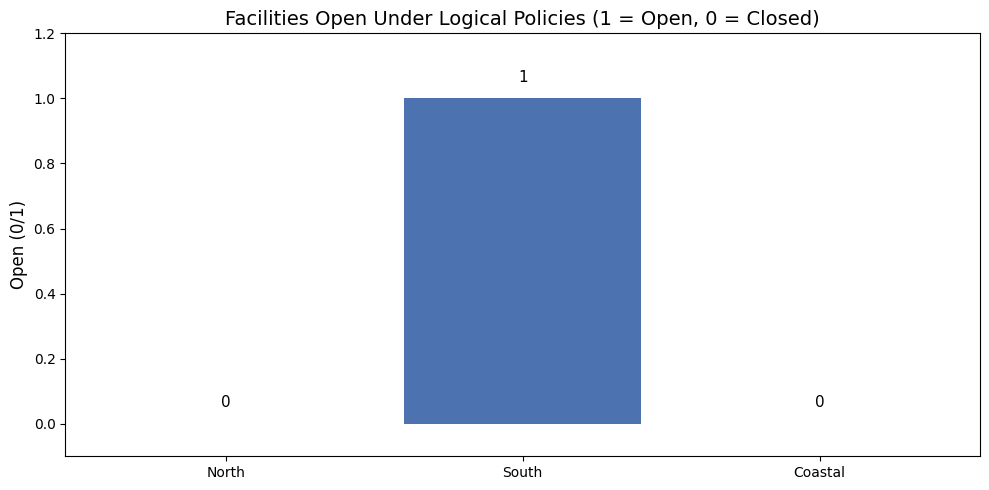

In [15]:
# Bar chart: which facilities are open?

fig, ax = plt.subplots()

ax.bar(sol_df["facility"], sol_df["x (open 0/1)"], color="#4C72B0")
ax.set_title("Facilities Open Under Logical Policies (1 = Open, 0 = Closed)")
ax.set_ylabel("Open (0/1)")
ax.set_ylim(-0.1, 1.2)

for idx, row in sol_df.iterrows():
    ax.text(idx, row["x (open 0/1)"] + 0.05, str(int(row["x (open 0/1)"])), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## Conclusion: Putting Logical Patterns Together

In this capstone example, you saw how:

- **IF-THEN**, **either-or**, and **mutually exclusive** rules can all act on the same set of binary decisions.
- The combination of these rules shapes which facility configurations are allowed.
- The optimizer finds the **cheapest configuration** that satisfies all logical policies.
- Simple validation checks (assertions) confirm that each pattern behaves as intended.

This mirrors real modeling work, where many logical rules stack on top of each other and the model must respect **all of them at once**.